In [1]:
!pip install ultralytics
!pip install roboflow
!pip install grad-cam
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.6 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of 

In [2]:
import torch
import os 
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import cv2 
import yaml 
import glob 
import numpy as np
import matplotlib.pyplot as plt 
import random
import torch.nn as nn

from ultralytics import YOLO
from PIL import Image
from roboflow import Roboflow
from torchvision import transforms
from skimage.transform import resize
from tqdm import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
SEED = 42 

In [4]:
import torch
import numpy as np
import random
import os

def set_seed(seed):
    # Python & OS
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # NumPy
    np.random.seed(seed)
    
    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Deterministic CUDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Global seed set to: {seed}")

set_seed(SEED)

Global seed set to: 42


In [5]:
rf = Roboflow(api_key="sNwZKFyXE0vHSdAqPXX0")
project = rf.workspace("main-workspace-vcien").project("birdnest-balanced-classification")
version = project.version(1)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to BirdNest-Balanced-Classification-1 in folder:: 100%|██████████| 817/817 [00:00<00:00, 3458.51it/s]


# Preprocessing & Augmentation 

## HITL Splitting from Roboflow

In [6]:
import os
import shutil
import random
from glob import glob
from PIL import Image
from roboflow import Roboflow

# --- Configuration ---
TARGET_SIZE = (640, 640)
OUTPUT_ROOT = "dataset_hitl"

# Global Split Ratios (Must sum to <= 1.0)
RATIO_TEST = 0.20     # 20% Global Test
RATIO_LABELED = 0.15  # 15% Initial Seed
# Remainder (65%) goes to Unlabeled Pool

# Labeled Split Ratios (Inside the 15% seed)
RATIO_LABELED_TRAIN = 0.80 # 80% of the seed goes to train
# Remainder (20%) of the seed goes to val

# --- 1. Download Dataset ---
print("Downloading dataset from Roboflow...")
rf = Roboflow(api_key="sNwZKFyXE0vHSdAqPXX0")
project = rf.workspace("main-workspace-vcien").project("birdnest-balanced-classification")
version = project.version(1)
dataset = version.download("folder")

print(f"Dataset downloaded to: {dataset.location}")

# --- 2. Setup Directories ---
def make_dirs(path):
    os.makedirs(path, exist_ok=True)

# Define paths
dirs_to_create = [
    f"{OUTPUT_ROOT}/labeled/train",
    f"{OUTPUT_ROOT}/labeled/val",
    f"{OUTPUT_ROOT}/test",
    f"{OUTPUT_ROOT}/unlabeled"
]

# We need subfolders 0, 1, 2 for labeled/train, labeled/val, and test
for d in dirs_to_create[:3]:
    for i in range(3):
        make_dirs(f"{d}/{i}")
make_dirs(f"{OUTPUT_ROOT}/unlabeled") # Unlabeled is flat

# --- 3. Helper Functions ---
def resize_and_save(src_path, dest_path, size):
    try:
        with Image.open(src_path) as img:
            # Convert to RGB to avoid errors with PNG/RGBA
            img = img.convert('RGB')
            resized_img = img.resize(size, Image.Resampling.LANCZOS)
            resized_img.save(dest_path, quality=95)
    except Exception as e:
        print(f"Error processing {src_path}: {e}")

# --- 4. Processing Logic ---
random.seed(SEED)

# Find all class folders in the downloaded dataset
raw_classes = set()
for root, dirs, files in os.walk(dataset.location):
    if len(files) > 0:
        folder_name = os.path.basename(root)
        if folder_name not in ['train', 'valid', 'test']:
            raw_classes.add(folder_name)

# Sort classes alphabetically to ensure deterministic mapping
sorted_classes = sorted(list(raw_classes))
class_map = {name: str(idx) for idx, name in enumerate(sorted_classes)}

print(f"Detected Classes Mapping: {class_map}")

global_unlabeled_counter = 0

for class_name, class_idx in class_map.items():
    print(f"\nProcessing Class: {class_name} (Mapped to {class_idx})")
    
    # Gather ALL images for this class
    all_images = []
    for split in ['train', 'valid', 'test']:
        search_path = os.path.join(dataset.location, split, class_name)
        if os.path.exists(search_path):
            images = glob(os.path.join(search_path, "*"))
            all_images.extend(images)
            
    # Remove duplicates
    all_images = list(set(all_images))
    
    # Sort deterministically BEFORE shuffling
    all_images.sort()
    
    # Shuffle deterministically
    random.shuffle(all_images)
    
    total_imgs = len(all_images)
    
    # --- Calculate Counts ---
    count_test = int(total_imgs * RATIO_TEST)
    count_labeled = int(total_imgs * RATIO_LABELED)
    
    # Split the list
    imgs_test = all_images[:count_test]
    imgs_labeled = all_images[count_test : count_test + count_labeled]
    imgs_unlabeled = all_images[count_test + count_labeled :]
    
    # Further split Labeled into Train/Val
    count_labeled_train = int(len(imgs_labeled) * RATIO_LABELED_TRAIN)
    imgs_labeled_train = imgs_labeled[:count_labeled_train]
    imgs_labeled_val = imgs_labeled[count_labeled_train:]
    
    print(f"  - Total: {total_imgs}")
    print(f"  - Test: {len(imgs_test)}")
    print(f"  - Labeled Train: {len(imgs_labeled_train)}")
    print(f"  - Labeled Val: {len(imgs_labeled_val)}")
    print(f"  - Unlabeled Pool: {len(imgs_unlabeled)}")
    
    # --- Move and Resize ---
    
    # 1. Test Set
    for src in imgs_test:
        fname = os.path.basename(src)
        dst = os.path.join(OUTPUT_ROOT, "test", class_idx, fname)
        resize_and_save(src, dst, TARGET_SIZE)
        
    # 2. Labeled Train
    for src in imgs_labeled_train:
        fname = os.path.basename(src)
        dst = os.path.join(OUTPUT_ROOT, "labeled", "train", class_idx, fname)
        resize_and_save(src, dst, TARGET_SIZE)
        
    # 3. Labeled Val
    for src in imgs_labeled_val:
        fname = os.path.basename(src)
        dst = os.path.join(OUTPUT_ROOT, "labeled", "val", class_idx, fname)
        resize_and_save(src, dst, TARGET_SIZE)
        
    # 4. Unlabeled Pool (Renaming with Ground Truth)
    for src in imgs_unlabeled:
        fname = os.path.basename(src)
        
        # New Format: (0)_original_filename.jpg
        # This keeps the ground truth '0' visible to YOU, but the file is in the generic 'unlabeled' folder.
        new_name = f"({class_idx})_{fname}"
        
        dst = os.path.join(OUTPUT_ROOT, "unlabeled", new_name)
        resize_and_save(src, dst, TARGET_SIZE)
        global_unlabeled_counter += 1

print("\nProcessing Complete.")
print(f"Unlabeled pool contains {global_unlabeled_counter} images.")
print(f"Data ready in folder: {OUTPUT_ROOT}")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /kaggle/working/BirdNest-Balanced-Classification-1
Detected Classes Mapping: {'0': '0', '1': '1', '2': '2', 'BirdNest-Balanced-Classification-1': '3'}

Processing Class: 0 (Mapped to 0)
  - Total: 262
  - Test: 52
  - Labeled Train: 31
  - Labeled Val: 8
  - Unlabeled Pool: 171

Processing Class: 1 (Mapped to 1)
  - Total: 278
  - Test: 55
  - Labeled Train: 32
  - Labeled Val: 9
  - Unlabeled Pool: 182

Processing Class: 2 (Mapped to 2)
  - Total: 271
  - Test: 54
  - Labeled Train: 32
  - Labeled Val: 8
  - Unlabeled Pool: 177

Processing Class: BirdNest-Balanced-Classification-1 (Mapped to 3)
  - Total: 0
  - Test: 0
  - Labeled Train: 0
  - Labeled Val: 0
  - Unlabeled Pool: 0

Processing Complete.
Unlabeled pool contains 530 images.
Data ready in folder: dataset_hitl


In [7]:
import os

# Configuration
DATASET_ROOT = "dataset_hitl"
CLASSES = ['0', '1', '2']

def count_files(directory):
    """Counts image files in a directory."""
    if not os.path.exists(directory):
        return 0
    return len([
        f for f in os.listdir(directory) 
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ])

def get_counts_dict(base_path):
    """Returns a dict of counts {'0': x, '1': x, '2': x} and the total."""
    counts = {}
    total = 0
    for cls in CLASSES:
        path = os.path.join(base_path, cls)
        c = count_files(path)
        counts[cls] = c
        total += c
    return counts, total

def get_unlabeled_counts(directory):
    """Parses filenames starting with (0), (1), (2) to count classes in a flat folder."""
    counts = {'0': 0, '1': 0, '2': 0}
    total = 0
    
    if os.path.exists(directory):
        files = [f for f in os.listdir(directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for f in files:
            # Check prefix like "(0)_image.jpg"
            if f.startswith('(0)'):
                counts['0'] += 1
            elif f.startswith('(1)'):
                counts['1'] += 1
            elif f.startswith('(2)'):
                counts['2'] += 1
            total += 1
            
    return counts, total

def print_section(title, counts_dict, total):
    """Helper to format the output line nicely."""
    details = ", ".join([f"{k}: {v:>3}" for k, v in counts_dict.items()])
    print(f"{title:<10} | {details}  (Total: {total})")

# --- Main Execution ---
print(f"\n{'='*60}")
print(f"DATASET DISTRIBUTION SUMMARY: {DATASET_ROOT}")
print(f"{'='*60}\n")

# 1. Labeled Data
print("LABELED:")
print("-" * 60)

# Train
train_counts, train_total = get_counts_dict(os.path.join(DATASET_ROOT, "labeled", "train"))
print_section("Train", train_counts, train_total)

# Val
val_counts, val_total = get_counts_dict(os.path.join(DATASET_ROOT, "labeled", "val"))
print_section("Val", val_counts, val_total)

print("\n")

# 2. Test Data
print("TEST:")
print("-" * 60)
test_counts, test_total = get_counts_dict(os.path.join(DATASET_ROOT, "test"))
print_section("Test", test_counts, test_total)

print("\n")

# 3. Unlabeled Data
print("UNLABELED POOL:")
print("-" * 60)
unlabeled_path = os.path.join(DATASET_ROOT, "unlabeled")
pool_counts, pool_total = get_unlabeled_counts(unlabeled_path)
print_section("Pool Size", pool_counts, pool_total)

print(f"\n{'='*60}\n")


DATASET DISTRIBUTION SUMMARY: dataset_hitl

LABELED:
------------------------------------------------------------
Train      | 0:  31, 1:  32, 2:  32  (Total: 95)
Val        | 0:   8, 1:   9, 2:   8  (Total: 25)


TEST:
------------------------------------------------------------
Test       | 0:  52, 1:  55, 2:  54  (Total: 161)


UNLABELED POOL:
------------------------------------------------------------
Pool Size  | 0: 171, 1: 182, 2: 177  (Total: 530)




## Deterministic Splitting from Roboflow

In [8]:
import os
import shutil
from sklearn.model_selection import train_test_split

source_path = '/kaggle/working/BirdNest-Balanced-Classification-1'
base_dir = '/kaggle/working/dataset_final'
categories = ['0', '1', '2']
roboflow_splits = ['train', 'test', 'valid'] 

# Create folders
for s in ['train', 'val', 'test']:
    for cat in categories:
        os.makedirs(os.path.join(base_dir, s, cat), exist_ok=True)

for cat in categories:
    all_images_for_cat = []
    
    # Collect every image from every possible Roboflow folder
    for r_split in roboflow_splits:
        split_cat_folder = os.path.join(source_path, r_split, cat)
        if os.path.exists(split_cat_folder):
            imgs = [os.path.join(split_cat_folder, f) for f in os.listdir(split_cat_folder) 
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            all_images_for_cat.extend(imgs)


    all_images_for_cat.sort() 
    
    print(f"Category {cat}: Found {len(all_images_for_cat)} total images.")

    if len(all_images_for_cat) > 0:
        # 3. Perform the 60/20/20 Split with fixed random_state
        train_imgs, temp_imgs = train_test_split(
            all_images_for_cat, 
            test_size=0.40, 
            random_state=SEED, 
            shuffle=True # Shuffle is okay as long as the seed is fixed and list is sorted
        )
        val_imgs, test_imgs = train_test_split(
            temp_imgs, 
            test_size=0.50, 
            random_state=SEED
        )
        
        def copy_to_split(file_list, split_name):
            for src_path in file_list:
                file_name = os.path.basename(src_path)
                dst_path = os.path.join(base_dir, split_name, cat, file_name)
                # Use copy2 to preserve metadata if possible
                shutil.copy2(src_path, dst_path)

        copy_to_split(train_imgs, 'train')
        copy_to_split(val_imgs, 'val')
        copy_to_split(test_imgs, 'test')

print(f"\nSuccess! Your split is now deterministic.")

Category 0: Found 262 total images.
Category 1: Found 278 total images.
Category 2: Found 271 total images.

Success! Your split is now deterministic.


## Dataset Distribution Check

In [9]:
import os

base_dir = 'dataset_final'
splits = ['train', 'test', 'val']
categories = ['0', '1', '2']

print("----- Dataset Distribution -----")

for split in splits:
    counts = []
    for cat in categories:
        path = os.path.join(base_dir, split, cat)
        # Count files with image extensions
        if os.path.exists(path):
            count = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        else:
            count = 0
        counts.append(f"{cat}: {count}")
    
    # Capitalize the split name and join the counts
    print(f"{split.capitalize()} - {', '.join(counts)}")

----- Dataset Distribution -----
Train - 0: 157, 1: 166, 2: 162
Test - 0: 53, 1: 56, 2: 55
Val - 0: 52, 1: 56, 2: 54


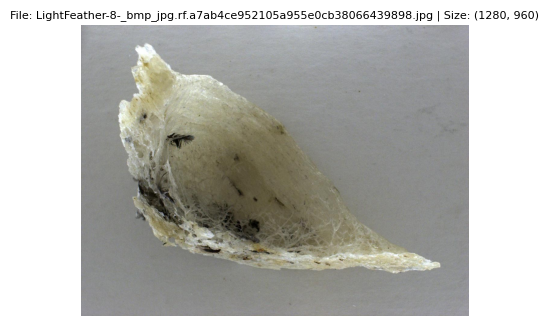

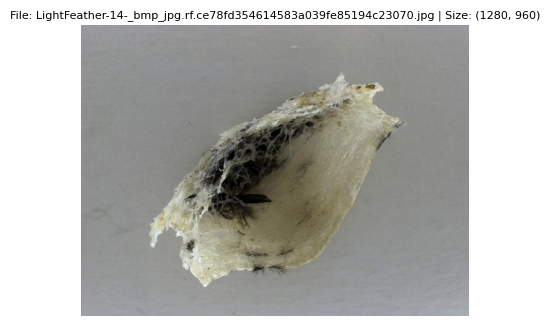

In [10]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def display_samples(target_folder, num_images=2):
    if not os.path.exists(target_folder):
        print(f"Directory not found: {target_folder}")
        return

    # Filter and sort (sorting ensures random.sample is consistent with a seed)
    all_files = sorted([f for f in os.listdir(target_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    # Use a fixed seed if you want to see the same "random" images every time 
    random.seed(SEED)
    samples = random.sample(all_files, min(len(all_files), num_images))

    for file_name in samples:
        img_path = os.path.join(target_folder, file_name)
        img = Image.open(img_path)
        
        plt.figure(figsize=(5, 5)) 
        plt.imshow(img)
        
        # Reduced fontsize for a cleaner research look
        plt.title(f"File: {file_name} | Size: {img.size}", fontsize=8) 
        plt.axis('off')
        plt.show()

display_samples('dataset_final/train/0', num_images=2)

## Dataset Resize

In [11]:
import os
from PIL import Image
from tqdm import tqdm

def preprocess(base_path, size=(640, 640)):
    splits = ['train', 'val', 'test']
    categories = ['0', '1', '2']
    
    for split in splits:
        for cat in categories:
            folder_path = os.path.join(base_path, split, cat)
            
            if not os.path.exists(folder_path):
                continue
                
            # Get all images in the subfolder
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # Added tqdm loading bar with a descriptive label
            print(f"Processing {split} - Category {cat}...")
            for file_name in tqdm(files, desc=f"Resize {cat}", unit="img"):
                img_path = os.path.join(folder_path, file_name)
                
                try:
                    with Image.open(img_path) as img:
                        resized_img = img.resize(size, Image.Resampling.LANCZOS)
                        resized_img.save(img_path)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

# Execute on your final dataset
preprocess('/kaggle/working/dataset_final')
print("\nAll images in Train, Val, and Test have been processed.")

Processing train - Category 0...


Resize 0: 100%|██████████| 157/157 [00:03<00:00, 39.53img/s]


Processing train - Category 1...


Resize 1: 100%|██████████| 166/166 [00:04<00:00, 40.38img/s]


Processing train - Category 2...


...

Processing test - Category 1...


Resize 1: 100%|██████████| 56/56 [00:01<00:00, 39.70img/s]


Processing test - Category 2...


Resize 2: 100%|██████████| 55/55 [00:01<00:00, 39.91img/s]


All images in Train, Val, and Test have been processed.


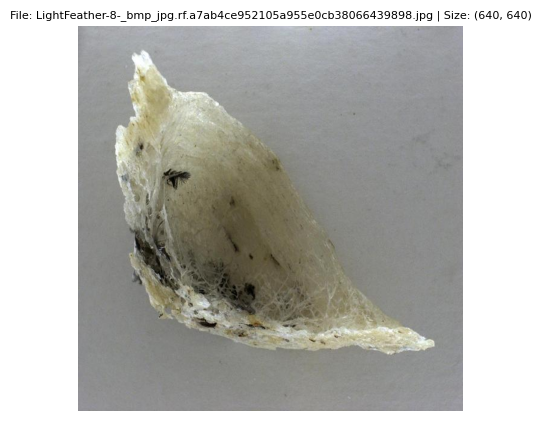

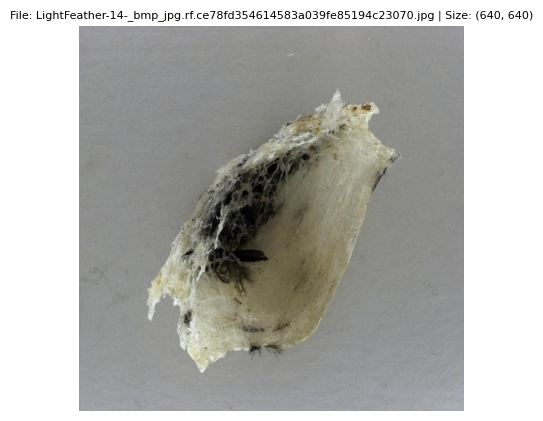

In [12]:
display_samples('dataset_final/train/0', num_images=2)

# Experiment  

## 3 Images 

In [ ]:
import gradio as gr
import cv2
import numpy as np
import random

class CAIPIGenerator:
    def __init__(self):
        pass

    def get_nest_mask(self, image, red_mask):
        """
        Creates nest mask using Sobel edge detection.
        Returns region with high edge density (textured nest) vs smooth background.
        """
        h, w = image.shape[:2]

        # Convert to grayscale and detect edges
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # Threshold and morphological operations
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel = np.ones((15, 15), np.uint8)
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel, iterations=1)
        
        # Get largest component (the nest)
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            hull = cv2.convexHull(largest)
            cv2.drawContours(valid_mask, [hull], -1, 255, thickness=cv2.FILLED)

        # Keep only parts of valid_mask that are NOT in the red_mask
        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
        return valid_mask
        
    def background_intervention(self, image, mask):
        """Idea 1: Noise on Red Mask (Unchanged)."""
        if np.count_nonzero(mask) == 0:
            return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask):
        """
        Idea 2 (Refined v6): Scatters impurities with enhanced validation.
        Ensures the ENTIRE impurity shape stays inside the nest with aggressive erosion.
        """
        if np.count_nonzero(green_mask) == 0:
            return image
            
        output = image.copy()
        h_img, w_img = image.shape[:2]
        
        # 1. Define the Boundary with AGGRESSIVE erosion
        valid_zone = self.get_nest_mask(image, red_mask)
        
        # Save debug image to see what the mask looks like
        # cv2.imwrite('debug_valid_zone_before_erosion.png', valid_zone)
        
        # VERY aggressive erosion to ensure safety margin
        # Increase kernel size significantly
        valid_zone = cv2.erode(valid_zone, np.ones((40, 40), np.uint8), iterations=2)
        
        # cv2.imwrite('debug_valid_zone_after_erosion.png', valid_zone)
        
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
                
            x, y, w, h = cv2.boundingRect(cnt)
            
            # Extract ROI from original image
            roi = image[y:y+h, x:x+w].copy()
            
            # Extract the actual mask shape for this specific impurity
            roi_green_mask = green_mask[y:y+h, x:x+w]
            
            # Create mask for seamlessClone
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            
            # Reduce clones if space is limited
            num_clones = 4
            clones_placed = 0
            attempts = 0
            max_attempts = 200
            
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                
                # Random offset - try smaller range first for better placement
                offset_x = random.randint(-80, 80)
                offset_y = random.randint(-80, 80)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                
                # Calculate where the patch will land
                tl_x = center_x - w // 2
                tl_y = center_y - h // 2
                br_x = tl_x + w
                br_y = tl_y + h
                
                # Check 1: Is it fully inside the image canvas with margin?
                margin = 5
                if (tl_x < margin or tl_y < margin or 
                    br_x > w_img - margin or br_y > h_img - margin):
                    continue
                
                # Check 2: Validate ALL impurity pixels against valid zone
                try:
                    # Get the valid zone region where this would be placed
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    
                    # Ensure dimensions match
                    if valid_zone_region.shape != roi_mask.shape:
                        continue
                    
                    # Check every single impurity pixel
                    impurity_pixels = roi_mask > 0
                    
                    # Count invalid placements
                    invalid_placements = np.sum(impurity_pixels & (valid_zone_region == 0))
                    
                    # STRICT: reject if even 1 pixel would be outside
                    if invalid_placements > 0:
                        continue
                        
                except Exception as e:
                    continue 
    
                # If we passed all checks, perform the clone
                try:
                    output = cv2.seamlessClone(
                        roi, 
                        output, 
                        roi_mask,
                        (center_x, center_y), 
                        cv2.MIXED_CLONE
                    )
                    clones_placed += 1
                except Exception as e:
                    pass
                    
        return output

    def restorative_intervention_texture(self, image, mask):
        """
        Idea 3: Sharp Edge-Preserving Restoration.
        Maintains fibrous texture and sharp boundaries.
        """
        if np.count_nonzero(mask) == 0:
            return image
        
        # Step 1: Multi-scale inpainting for better edge preservation
        # Start with very small radius for edge detail
        output = cv2.inpaint(image, mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)
        
        # Step 2: Apply edge-preserving filter to reduce blur while keeping structure
        output = cv2.bilateralFilter(output, d=7, sigmaColor=75, sigmaSpace=75)
        
        # Step 3: Sharpen edges specifically in the inpainted region
        # Create sharpening kernel
        kernel_sharpen = np.array([[-1,-1,-1],
                                   [-1, 9,-1],
                                   [-1,-1,-1]]) / 1.0
        
        # Apply sharpening
        sharpened = cv2.filter2D(output, -1, kernel_sharpen)
        
        # Blend original and sharpened based on mask
        mask_3ch = np.stack([mask] * 3, axis=-1) / 255.0
        output = (sharpened * mask_3ch + output * (1 - mask_3ch)).astype(np.uint8)
        
        # Step 4: Add subtle texture to match fibrous appearance
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        texture_strength = np.std(gray)  # Adaptive based on image
        
        noise = np.random.normal(0, texture_strength * 0.15, output.shape).astype(np.int16)
        output = np.clip(output.astype(np.int16) + noise * mask_3ch, 0, 255).astype(np.uint8)
        
        return output


# Initialize
generator = CAIPIGenerator()

def process_caipi(input_dict):
    if input_dict is None:
        return None, None, None

    # 1. Prepare Image
    original_img = input_dict["background"]
    if original_img.shape[2] == 4:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # 2. Decode Masks
    drawing_layer = input_dict["layers"][0]
    r_channel = drawing_layer[:, :, 0]
    g_channel = drawing_layer[:, :, 1]
    a_channel = drawing_layer[:, :, 3]
    
    drawn_pixels = a_channel > 10
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    is_red = (r_channel > g_channel) & drawn_pixels
    is_green = (g_channel > r_channel) & drawn_pixels
    
    mask_red[is_red] = 255
    mask_green[is_green] = 255

    # 3. Generate
    # Idea 1: Background Noise
    output_idea_1 = generator.background_intervention(original_img, mask_red)
    
    # Idea 2: Destructive Scatter (Updated with Boundary Check)
    output_idea_2 = generator.destructive_intervention_scatter(original_img, mask_green, mask_red)
    
    # Idea 3: Restorative Texture Clone
    output_idea_3 = generator.restorative_intervention_texture(original_img, mask_green)

    return output_idea_1, output_idea_2, output_idea_3

# --- UI ---
demo = gr.Interface(
    fn=process_caipi,
    inputs=gr.ImageEditor(
        type="numpy", 
        label="Masking Tool", 
        brush=gr.Brush(colors=["#90EE9080", "#FF999980"], default_size=20), 
        interactive=True
    ),
    outputs=[
        gr.Image(label="Idea 1: Background Noise (Red)"),
        gr.Image(label="Idea 2: Scattered Impurities (Green)"),
        gr.Image(label="Idea 3: Texture Restoration (Green)")
    ],
    title="CAIPI Generator: Boundary-Aware",
    description="Green impurities (Idea 2) will now stay strictly INSIDE the nest. (Uses Red Mask as boundary, or Auto-Detects nest if Red Mask is missing)."
)

demo.launch()

## 1 + 5 + 1 Images  

In [13]:
import gradio as gr
import cv2
import numpy as np
import random
from scipy.ndimage import map_coordinates, gaussian_filter

class CAIPIGenerator:
    def __init__(self):
        pass

    def get_nest_mask(self, image, red_mask):
        """
        Creates a tight mask by following the actual contour of the nest 
        instead of a loose convex hull.
        """
        h, w = image.shape[:2]

        # 1. Texture-based segmentation (Sobel)
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # 2. Thresholding
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # 3. HEAVY Closing to solidify the nest
        kernel_close = np.ones((25, 25), np.uint8) 
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        
        # 4. Opening to remove background noise
        kernel_open = np.ones((5, 5), np.uint8) 
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        
        # 5. Get largest component
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            
            # Use approxPolyDP instead of convexHull to keep the concave shape
            epsilon = 0.002 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, epsilon, True)
            
            cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)

        # 6. Safety Margin
        valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)

        # 7. Exclude Red Mask
        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
        return valid_mask
        
    def background_intervention(self, image, mask):
        """Idea 1: Noise on Red Mask."""
        if np.count_nonzero(mask) == 0:
            return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask, clones_per_source=4):
        """Idea 2: Scatters impurities with variable severity."""
        if np.count_nonzero(green_mask) == 0:
            return image
            
        output = image.copy()
        h_img, w_img = image.shape[:2]
        
        valid_zone = self.get_nest_mask(image, red_mask)
        valid_zone = cv2.erode(valid_zone, np.ones((10, 10), np.uint8), iterations=2)
        
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
                
            x, y, w, h = cv2.boundingRect(cnt)
            roi = image[y:y+h, x:x+w].copy()
            roi_green_mask = green_mask[y:y+h, x:x+w]
            
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            
            num_clones = clones_per_source 
            clones_placed = 0
            attempts = 0
            max_attempts = 200 + (num_clones * 10) 
            
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                spread_factor = 80 + (num_clones * 2) 
                offset_x = random.randint(-spread_factor, spread_factor)
                offset_y = random.randint(-spread_factor, spread_factor)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                
                tl_x, tl_y = center_x - w // 2, center_y - h // 2
                br_x, br_y = tl_x + w, tl_y + h
                
                margin = 5
                if (tl_x < margin or tl_y < margin or br_x > w_img - margin or br_y > h_img - margin):
                    continue
                
                try:
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    if valid_zone_region.shape != roi_mask.shape: continue
                    
                    if np.sum((roi_mask > 0) & (valid_zone_region == 0)) > 0:
                        continue
                        
                    output = cv2.seamlessClone(roi, output, roi_mask, (center_x, center_y), cv2.MIXED_CLONE)
                    clones_placed += 1
                except Exception:
                    pass
                    
        return output

    def elastic_transform_region(self, image, mask, alpha=2000, sigma=30):
        """
        Applies elastic deformation ONLY within the masked region.
        alpha: Scale of deformation (higher = more distorted)
        sigma: Smoothness of deformation
        """
        if np.count_nonzero(mask) == 0:
            return image

        image_float = image.astype(np.float32)
        shape = image.shape[:2]
        
        # Prepare Mask: Normalize to 0-1
        mask_norm = mask.astype(np.float32) / 255.0
        # Slight blur to mask to ensure smooth transition at edges
        mask_norm = cv2.GaussianBlur(mask_norm, (3, 3), 0)

        random_state = np.random.RandomState(None)

        # Generate random displacement fields
        dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

        # MULTIPLY by mask: This ensures dx/dy are 0 (no movement) outside the mask
        dx = dx * mask_norm
        dy = dy * mask_norm

        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

        distorted = np.empty_like(image_float)
        
        # Apply mapping channel by channel
        for i in range(image.shape[2]):
            distorted[:, :, i] = map_coordinates(
                image_float[:, :, i], 
                indices, 
                order=1, 
                mode='reflect'
            ).reshape(shape)

        return distorted.astype(np.uint8)

# Initialize
generator = CAIPIGenerator()

def process_caipi(input_dict):
    if input_dict is None:
        return [None] * 5

    # 1. Prepare Image
    original_img = input_dict["background"]
    if original_img.shape[2] == 4:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # 2. Decode Masks (Robust RGB/BGR Handling)
    drawing_layer = input_dict["layers"][0]
    
    c0 = drawing_layer[:, :, 0]
    c1 = drawing_layer[:, :, 1]
    c2 = drawing_layer[:, :, 2]
    a_channel = drawing_layer[:, :, 3]
    drawn_pixels = a_channel > 10
    
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_blue = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    # Determine dominant channels
    is_ch0_max = (c0 > c1) & (c0 > c2) & drawn_pixels
    is_ch1_max = (c1 > c0) & (c1 > c2) & drawn_pixels
    is_ch2_max = (c2 > c0) & (c2 > c1) & drawn_pixels
    
    # Distinguish Red vs Blue-swapped (both have Ch0 max if BGR)
    diff_0_1 = c0.astype(int) - c1.astype(int)
    
    # Red (#FF9999) has big gap R-G. Blue (#87CEEB) has small gap B-G.
    strong_red = is_ch0_max & (diff_0_1 > 50) 
    potential_blue_swapped = is_ch0_max & (diff_0_1 < 50)
    
    # Assign Masks
    mask_green[is_ch1_max] = 255
    mask_red[strong_red] = 255
    mask_blue[is_ch2_max | potential_blue_swapped] = 255

    # --- 3. Generate Sequence of Images ---
    outputs = []

    # Step A: Apply Background Noise
    noisy_base_img = generator.background_intervention(original_img, mask_red)

    # Step B: Scatter impurities
    severity_levels = [5, 20, 50] 
    for level in severity_levels:
        result = generator.destructive_intervention_scatter(
            noisy_base_img, 
            mask_green, 
            mask_red, 
            clones_per_source=level
        )
        outputs.append(result)

    # Step C: Elastic Transformation on Blue Mask (Replaces previous Morph)
    elastic_result = generator.elastic_transform_region(
        noisy_base_img, 
        mask_blue, 
        alpha=2000, 
        sigma=30
    )
    outputs.append(elastic_result)
    
    # Step D: Debug Nest Mask
    debug_mask = generator.get_nest_mask(original_img, mask_red)
    outputs.append(debug_mask)

    return outputs

# --- UI Update ---
demo = gr.Interface(
    fn=process_caipi,
    inputs=gr.ImageEditor(
        type="numpy", 
        label="Masking Tool", 
        brush=gr.Brush(colors=["#90EE9080", "#FF999980", "#87CEEB60"], default_size=20), 
        interactive=True
    ),
    outputs=gr.Gallery(
        label="CAIPI Progression: Scatter Levels + Elastic Transform + Mask", 
        columns=5, # Updated to 5 to fit all images
    ),
    title="CAIPI Generator: Scatter + Elastic Transform",
    description="Generates 5 images: 3 Scatter levels, 1 Elastic Deformed (Blue Mask), and 1 Nest Mask."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://b58dd1b7fc82afa29c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Functioning Playground

In [14]:
import gradio as gr
import cv2
import numpy as np
import random
from scipy.ndimage import map_coordinates, gaussian_filter

class CAIPIGenerator:
    def __init__(self):
        pass

    def get_nest_mask(self, image, red_mask):
        """Creates a tight mask by following the actual contour of the nest."""
        h, w = image.shape[:2]

        # 1. Texture-based segmentation
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # 2. Thresholding
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # 3. Morphological cleanup
        kernel_close = np.ones((25, 25), np.uint8) 
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        kernel_open = np.ones((5, 5), np.uint8) 
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        
        # 4. Get largest component
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            epsilon = 0.002 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, epsilon, True)
            cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)

        # 5. Safety Margin & Exclude Red
        valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)
        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
        return valid_mask
        
    def background_intervention(self, image, mask):
        """Noise on Red Mask."""
        if np.count_nonzero(mask) == 0:
            return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask, clones_per_source=4):
        """Scatters impurities with variable severity."""
        if np.count_nonzero(green_mask) == 0:
            return image
            
        output = image.copy()
        h_img, w_img = image.shape[:2]
        
        valid_zone = self.get_nest_mask(image, red_mask)
        valid_zone = cv2.erode(valid_zone, np.ones((10, 10), np.uint8), iterations=2)
        
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
                
            x, y, w, h = cv2.boundingRect(cnt)
            roi = image[y:y+h, x:x+w].copy()
            roi_green_mask = green_mask[y:y+h, x:x+w]
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            
            num_clones = clones_per_source 
            clones_placed = 0
            attempts = 0
            max_attempts = 200 + (num_clones * 10) 
            
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                spread_factor = 80 + (num_clones * 2) 
                offset_x = random.randint(-spread_factor, spread_factor)
                offset_y = random.randint(-spread_factor, spread_factor)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                
                tl_x, tl_y = center_x - w // 2, center_y - h // 2
                br_x, br_y = tl_x + w, tl_y + h
                
                margin = 5
                if (tl_x < margin or tl_y < margin or br_x > w_img - margin or br_y > h_img - margin):
                    continue
                
                try:
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    if valid_zone_region.shape != roi_mask.shape: continue
                    if np.sum((roi_mask > 0) & (valid_zone_region == 0)) > 0: continue
                    output = cv2.seamlessClone(roi, output, roi_mask, (center_x, center_y), cv2.MIXED_CLONE)
                    clones_placed += 1
                except Exception:
                    pass
        return output

    def elastic_transform_region(self, image, mask, alpha=6000, sigma=40):
        """Applies elastic deformation. Increased Alpha for visibility."""
        if np.count_nonzero(mask) == 0:
            return image

        image_float = image.astype(np.float32)
        shape = image.shape[:2]
        
        mask_norm = mask.astype(np.float32) / 255.0
        mask_norm = cv2.GaussianBlur(mask_norm, (3, 3), 0)

        random_state = np.random.RandomState(None)
        dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

        dx = dx * mask_norm
        dy = dy * mask_norm

        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

        distorted = np.empty_like(image_float)
        for i in range(image.shape[2]):
            distorted[:, :, i] = map_coordinates(
                image_float[:, :, i], indices, order=1, mode='reflect'
            ).reshape(shape)

        return distorted.astype(np.uint8)

# Initialize
generator = CAIPIGenerator()

def process_caipi(input_dict):
    if input_dict is None:
        return [None] * 5

    # 1. Prepare Image
    original_img = input_dict["background"]
    if original_img.shape[2] == 4:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # 2. Decode Masks (HSV METHOD - FOOLPROOF)
    drawing_layer = input_dict["layers"][0]
    
    # Extract alpha to know where drawing exists
    alpha = drawing_layer[:, :, 3]
    drawn_mask = alpha > 10
    
    # Convert Drawing layer to HSV
    # We must ensure the drawing layer is RGB before converting to HSV
    drawing_rgb = drawing_layer[:, :, :3]
    hsv_drawing = cv2.cvtColor(drawing_rgb, cv2.COLOR_RGB2HSV)
    hue = hsv_drawing[:, :, 0] # Hue channel (0-179 in OpenCV)
    
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_blue = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    # --- HSV Thresholds ---
    # Red: Hue is near 0 or 180 (wraps around)
    # Green: Hue is near 60
    # Blue: Hue is near 120 (Sky blue is ~100-110, pure blue is 120)
    
    # Red Logic: (Hue < 20 OR Hue > 160) AND drawn
    is_red = ((hue < 20) | (hue > 160)) & drawn_mask
    
    # Green Logic: (Hue > 35 AND Hue < 85) AND drawn
    is_green = (hue > 35) & (hue < 85) & drawn_mask
    
    # Blue Logic: (Hue > 85 AND Hue < 140) AND drawn
    # Covers cyan/sky-blue (#87CEEB) to deep blue
    is_blue = (hue > 85) & (hue < 140) & drawn_mask
    
    mask_red[is_red] = 255
    mask_green[is_green] = 255
    mask_blue[is_blue] = 255

    # --- 3. Generate Sequence ---
    outputs = []

    # Step A: Noise (Red)
    noisy_base_img = generator.background_intervention(original_img, mask_red)

    # Step B: Scatter (Green)
    severity_levels = [5, 20, 50] 
    for level in severity_levels:
        result = generator.destructive_intervention_scatter(
            noisy_base_img, 
            mask_green, 
            mask_red, 
            clones_per_source=level
        )
        outputs.append(result)

    # Step C: Elastic Transform (Blue)
    # Applied to the noisy base image
    elastic_result = generator.elastic_transform_region(
        noisy_base_img, 
        mask_blue, 
        alpha=6000,  # Strongly increased intensity
        sigma=40
    )
    outputs.append(elastic_result)
    
    # Step D: Debug Mask
    debug_mask = generator.get_nest_mask(original_img, mask_red)
    outputs.append(debug_mask)

    return outputs

# --- UI Update ---
demo = gr.Interface(
    fn=process_caipi,
    inputs=gr.ImageEditor(
        type="numpy", 
        label="Masking Tool", 
        brush=gr.Brush(colors=["#90EE9080", "#FF999980", "#87CEEB60"], default_size=20), 
        interactive=True
    ),
    outputs=gr.Gallery(
        label="CAIPI Progression: Scatter Levels + Elastic Transform + Mask", 
        columns=5, 
    ),
    title="CAIPI Generator: Scatter + Elastic Transform",
    description="Generates 5 images: 3 Scatter levels, 1 Elastic Deformed (Blue Mask), and 1 Nest Mask."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://cd43fe741a7201bc29.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [51]:
import gradio as gr
import cv2
import numpy as np
import random
from scipy.ndimage import map_coordinates, gaussian_filter

class CAIPIGenerator:
    def __init__(self):
        pass

    def get_nest_mask(self, image, red_mask):
        """Creates a tight mask by following the actual contour of the nest."""
        h, w = image.shape[:2]

        # 1. Texture-based segmentation
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # 2. Thresholding
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # 3. Morphological cleanup
        kernel_close = np.ones((25, 25), np.uint8) 
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        kernel_open = np.ones((5, 5), np.uint8) 
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        
        # 4. Get largest component
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            epsilon = 0.002 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, epsilon, True)
            cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)

        # 5. Safety Margin & Exclude Red
        valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)
        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
        return valid_mask
        
    def background_intervention(self, image, mask):
        """Noise on Red Mask."""
        if np.count_nonzero(mask) == 0:
            return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask, clones_per_source=4):
        """Scatters impurities with variable severity."""
        if np.count_nonzero(green_mask) == 0:
            return image
            
        output = image.copy()
        h_img, w_img = image.shape[:2]
        
        valid_zone = self.get_nest_mask(image, red_mask)
        valid_zone = cv2.erode(valid_zone, np.ones((10, 10), np.uint8), iterations=2)
        
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
                
            x, y, w, h = cv2.boundingRect(cnt)
            roi = image[y:y+h, x:x+w].copy()
            roi_green_mask = green_mask[y:y+h, x:x+w]
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            
            num_clones = clones_per_source 
            clones_placed = 0
            attempts = 0
            max_attempts = 200 + (num_clones * 10) 
            
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                spread_factor = 80 + (num_clones * 2) 
                offset_x = random.randint(-spread_factor, spread_factor)
                offset_y = random.randint(-spread_factor, spread_factor)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                
                tl_x, tl_y = center_x - w // 2, center_y - h // 2
                br_x, br_y = tl_x + w, tl_y + h
                
                margin = 5
                if (tl_x < margin or tl_y < margin or br_x > w_img - margin or br_y > h_img - margin):
                    continue
                
                try:
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    if valid_zone_region.shape != roi_mask.shape: continue
                    if np.sum((roi_mask > 0) & (valid_zone_region == 0)) > 0: continue
                    output = cv2.seamlessClone(roi, output, roi_mask, (center_x, center_y), cv2.MIXED_CLONE)
                    clones_placed += 1
                except Exception:
                    pass
        return output

    def elastic_transform_region(self, image, mask, alpha=2000, sigma=40):
        """
        Applies elastic deformation with configurable severity.
        
        Args:
            alpha: Deformation intensity (higher = more distortion)
                   - Mild: 2000-3000
                   - Moderate: 4000-5000
                   - Severe: 6000-8000
            sigma: Smoothness of deformation (40 is good default)
        """
        if np.count_nonzero(mask) == 0:
            return image

        image_float = image.astype(np.float32)
        shape = image.shape[:2]
        
        # Smooth mask boundaries for natural blending
        mask_norm = mask.astype(np.float32) / 255.0
        mask_norm = cv2.GaussianBlur(mask_norm, (5, 5), 0)

        # Generate random displacement fields
        random_state = np.random.RandomState(None)
        dx = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha
        dy = gaussian_filter((random_state.rand(*shape) * 2 - 1), sigma) * alpha

        # Apply mask to constrain deformation to annotated region
        dx = dx * mask_norm
        dy = dy * mask_norm

        # Create coordinate maps
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = np.reshape(y + dy, (-1, 1)), np.reshape(x + dx, (-1, 1))

        # Apply deformation to each channel
        distorted = np.empty_like(image_float)
        for i in range(image.shape[2]):
            distorted[:, :, i] = map_coordinates(
                image_float[:, :, i], indices, order=1, mode='reflect'
            ).reshape(shape)

        return distorted.astype(np.uint8)

# Initialize
generator = CAIPIGenerator()

def process_caipi(input_dict):
    if input_dict is None:
        return [None] * 7  # 7 outputs now

    # 1. Prepare Image
    original_img = input_dict["background"]
    if original_img.shape[2] == 4:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # 2. Decode Masks (HSV METHOD)
    drawing_layer = input_dict["layers"][0]
    
    # Extract alpha to know where drawing exists
    alpha = drawing_layer[:, :, 3]
    drawn_mask = alpha > 10
    
    # Convert Drawing layer to HSV
    drawing_rgb = drawing_layer[:, :, :3]
    hsv_drawing = cv2.cvtColor(drawing_rgb, cv2.COLOR_RGB2HSV)
    hue = hsv_drawing[:, :, 0]  # Hue channel (0-179 in OpenCV)
    
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_blue = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    # HSV Color Separation
    # Red: Hue near 0 or 180 (wraps around)
    is_red = ((hue < 20) | (hue > 160)) & drawn_mask
    # Green: Hue around 60
    is_green = (hue > 35) & (hue < 85) & drawn_mask
    # Blue: Hue around 120 (includes sky blue)
    is_blue = (hue > 85) & (hue < 140) & drawn_mask
    
    mask_red[is_red] = 255
    mask_green[is_green] = 255
    mask_blue[is_blue] = 255

    # --- 3. Generate Sequence of 7 Images ---
    outputs = []

    # Step A: Apply Background Noise
    noisy_base_img = generator.background_intervention(original_img, mask_red)

    # Step B: 3 Levels of Impurity Scatter (Green Mask)
    impurity_levels = [5, 20, 50]  # Low, Medium, High
    for level in impurity_levels:
        result = generator.destructive_intervention_scatter(
            noisy_base_img, 
            mask_green, 
            mask_red, 
            clones_per_source=level
        )
        outputs.append(result)

    # Step C: 3 Levels of Shape Perturbation (Blue Mask)
    # Using elastic deformation with increasing alpha values
    # shape_alphas = [2000, 4000, 6000]  # Mild, Moderate, Severe
    shape_alphas = [3000, 6000, 9000]  # Mild, Moderate, Severe
    
    for alpha_val in shape_alphas:
        shape_result = generator.elastic_transform_region(
            noisy_base_img, 
            mask_blue, 
            alpha=alpha_val,
            sigma=50
        )
        outputs.append(shape_result)

    # Step D: Debug Nest Mask
    debug_mask = generator.get_nest_mask(original_img, mask_red)
    outputs.append(debug_mask)

    return outputs

# --- UI ---
demo = gr.Interface(
    fn=process_caipi,
    inputs=gr.ImageEditor(
        type="numpy", 
        label="Masking Tool", 
        brush=gr.Brush(colors=["#90EE9080", "#FF999980", "#87CEEB60"], default_size=20), 
        interactive=True
    ),
    outputs=gr.Gallery(
        label="CAIPI: 3 Impurity Levels + 3 Shape Levels + Mask", 
        columns=7, 
        rows=1
    ),
    title="CAIPI Generator: Scatter + Elastic Transform",
    description="Generates 7 images: 3 Impurities, 3 Shape, 1 Elastic Deformed (Blue Mask), and 1 Nest Mask."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7877
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://114d542e8e402d2ba8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# import gradio as gr
# import cv2
# import numpy as np
# import random

# class CAIPIGenerator:
#     def __init__(self):
#         pass

#     def get_nest_mask(self, image, red_mask):
#         """
#         FIXED VERSION: Creates a tight mask by following the actual contour of the nest 
#         instead of a loose convex hull.
#         """
#         h, w = image.shape[:2]

#         # 1. Texture-based segmentation (Sobel)
#         gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
#         sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
#         sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
#         magnitude = cv2.magnitude(sobelx, sobely)
#         magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
#         # 2. Thresholding
#         _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
#         # 3. HEAVY Closing to solidify the nest
#         # Increased kernel to bridge gaps between strands without expanding boundary too much
#         kernel_close = np.ones((25, 25), np.uint8) 
#         solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        
#         # 4. Opening to remove background noise
#         kernel_open = np.ones((5, 5), np.uint8)
#         solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        
#         # 5. Get largest component
#         contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         valid_mask = np.zeros((h, w), dtype=np.uint8)
        
#         if contours:
#             largest = max(contours, key=cv2.contourArea)
            
#             # --- THE FIX ---
#             # Use approxPolyDP instead of convexHull to keep the concave shape
#             epsilon = 0.002 * cv2.arcLength(largest, True)
#             approx = cv2.approxPolyDP(largest, epsilon, True)
            
#             cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)

#         # 6. Safety Margin: Erode slightly to ensure impurities stay "deep" inside
#         valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)

#         # 7. Exclude Red Mask
#         if np.count_nonzero(red_mask) > 0:
#             valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
#         return valid_mask
        
#     def background_intervention(self, image, mask):
#         """Idea 1: Noise on Red Mask (Unchanged)."""
#         if np.count_nonzero(mask) == 0:
#             return image 
#         noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
#         binary_mask = mask > 127
#         output = image.copy()
#         output[binary_mask] = noise[binary_mask]
#         return output

#     def destructive_intervention_scatter(self, image, green_mask, red_mask, clones_per_source=4):
#         """
#         Idea 2: Scatters impurities with variable severity.
#         """
#         if np.count_nonzero(green_mask) == 0:
#             return image
            
#         output = image.copy()
#         h_img, w_img = image.shape[:2]
        
#         # 1. Define the Boundary
#         valid_zone = self.get_nest_mask(image, red_mask)
#         # Safety erosion for placement
#         valid_zone = cv2.erode(valid_zone, np.ones((10, 10), np.uint8), iterations=2)
        
#         contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
#         for cnt in contours:
#             if cv2.contourArea(cnt) < 10:
#                 continue
                
#             x, y, w, h = cv2.boundingRect(cnt)
            
#             # Extract ROI
#             roi = image[y:y+h, x:x+w].copy()
#             roi_green_mask = green_mask[y:y+h, x:x+w]
            
#             roi_mask = np.zeros((h, w), dtype=np.uint8)
#             roi_mask[roi_green_mask > 0] = 255
            
#             # --- SEVERITY CONTROL ---
#             num_clones = clones_per_source 
#             clones_placed = 0
#             attempts = 0
#             max_attempts = 200 + (num_clones * 10) 
            
#             while clones_placed < num_clones and attempts < max_attempts:
#                 attempts += 1
                
#                 spread_factor = 80 + (num_clones * 2) 
#                 offset_x = random.randint(-spread_factor, spread_factor)
#                 offset_y = random.randint(-spread_factor, spread_factor)
                
#                 center_x = x + w//2 + offset_x
#                 center_y = y + h//2 + offset_y
                
#                 tl_x = center_x - w // 2
#                 tl_y = center_y - h // 2
#                 br_x = tl_x + w
#                 br_y = tl_y + h
                
#                 margin = 5
#                 if (tl_x < margin or tl_y < margin or 
#                     br_x > w_img - margin or br_y > h_img - margin):
#                     continue
                
#                 try:
#                     valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
#                     if valid_zone_region.shape != roi_mask.shape:
#                         continue
                    
#                     impurity_pixels = roi_mask > 0
#                     invalid_placements = np.sum(impurity_pixels & (valid_zone_region == 0))
                    
#                     if invalid_placements > 0:
#                         continue
                        
#                 except Exception as e:
#                     continue 
    
#                 try:
#                     output = cv2.seamlessClone(
#                         roi, 
#                         output, 
#                         roi_mask,
#                         (center_x, center_y), 
#                         cv2.MIXED_CLONE
#                     )
#                     clones_placed += 1
#                 except Exception as e:
#                     pass
                    
#         return output

#     def restorative_intervention_texture(self, image, mask):
#         """Idea 3: Sharp Edge-Preserving Restoration."""
#         if np.count_nonzero(mask) == 0:
#             return image
        
#         output = cv2.inpaint(image, mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)
#         output = cv2.bilateralFilter(output, d=7, sigmaColor=75, sigmaSpace=75)
        
#         kernel_sharpen = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]]) / 1.0
#         sharpened = cv2.filter2D(output, -1, kernel_sharpen)
        
#         mask_3ch = np.stack([mask] * 3, axis=-1) / 255.0
#         output = (sharpened * mask_3ch + output * (1 - mask_3ch)).astype(np.uint8)
        
#         gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
#         texture_strength = np.std(gray)
        
#         noise = np.random.normal(0, texture_strength * 0.15, output.shape).astype(np.int16)
#         output = np.clip(output.astype(np.int16) + noise * mask_3ch, 0, 255).astype(np.uint8)
        
#         return output


# # Initialize
# generator = CAIPIGenerator()

# def process_caipi(input_dict):
#     if input_dict is None:
#         return [None] * 8 # Return 8 Nones if empty

#     # 1. Prepare Image
#     original_img = input_dict["background"]
#     if original_img.shape[2] == 4:
#         original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
#     original_img = original_img.astype(np.uint8)
    
#     # 2. Decode Masks
#     drawing_layer = input_dict["layers"][0]
#     r_channel = drawing_layer[:, :, 0]
#     g_channel = drawing_layer[:, :, 1]
#     a_channel = drawing_layer[:, :, 3]
    
#     drawn_pixels = a_channel > 10
#     mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
#     mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
#     is_red = (r_channel > g_channel) & drawn_pixels
#     is_green = (g_channel > r_channel) & drawn_pixels
    
#     mask_red[is_red] = 255
#     mask_green[is_green] = 255

#     # --- 3. Generate Sequence of 8 Images ---
#     outputs = []

#     # Image 1: Background Noise (Idea 1)
#     outputs.append(generator.background_intervention(original_img, mask_red))

#     # Images 2-6: Destructive Scatter (Idea 2) with Increasing Severity
#     severity_levels = [2, 5, 10, 20, 40]
    
#     for level in severity_levels:
#         result = generator.destructive_intervention_scatter(
#             original_img, 
#             mask_green, 
#             mask_red, 
#             clones_per_source=level
#         )
#         outputs.append(result)

#     # Image 7: Restorative Texture (Idea 3)
#     outputs.append(generator.restorative_intervention_texture(original_img, mask_green))

#     # Image 8: Debug Nest Mask (New Request)
#     # We call get_nest_mask directly to see what the algorithm "sees" as the safe zone
#     debug_mask = generator.get_nest_mask(original_img, mask_red)
#     outputs.append(debug_mask)

#     return outputs

# # --- UI Update ---
# demo = gr.Interface(
#     fn=process_caipi,
#     inputs=gr.ImageEditor(
#         type="numpy", 
#         label="Masking Tool", 
#         brush=gr.Brush(colors=["#90EE9080", "#FF999980"], default_size=20), 
#         interactive=True
#     ),
#     outputs=gr.Gallery(
#         label="CAIPI Progression: Noise -> Scattering (Low to High) -> Restoration -> Mask", 
#         columns=4, 
#         rows=2
#     ),
#     title="CAIPI Generator: Multi-Severity + Mask View",
#     description="Generates 8 images: 1 Noise, 5 Scatter (increasing severity), 1 Restored, and 1 Debug Mask (showing the safe zone)."
# )

# demo.launch()

In [ ]:
    def restorative_intervention_texture(self, image, mask):
        """
        Idea 3: Localized Edge-Preserving Restoration.
        Processes each impurity independently without affecting clean areas.
        """
        if np.count_nonzero(mask) == 0:
            return image
        
        output = image.copy()
        h, w = image.shape[:2]
        
        # Process each impurity contour separately
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            x, y, cw, ch = cv2.boundingRect(cnt)
            
            # Extract ROI with padding for context
            padding = 25
            y1 = max(0, y - padding)
            y2 = min(h, y + ch + padding)
            x1 = max(0, x - padding)
            x2 = min(w, x + cw + padding)
            
            roi = output[y1:y2, x1:x2].copy()
            roi_h, roi_w = roi.shape[:2]
            
            # Create ROI mask
            roi_mask = np.zeros((roi_h, roi_w), dtype=np.uint8)
            mask_y1 = y - y1
            mask_y2 = mask_y1 + ch
            mask_x1 = x - x1
            mask_x2 = mask_x1 + cw
            roi_mask[mask_y1:mask_y2, mask_x1:mask_x2] = mask[y:y+ch, x:x+cw]
            
            # Inpaint this specific region
            inpainted_roi = cv2.inpaint(roi, roi_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
            
            # Create smooth transition mask
            feather = cv2.GaussianBlur(roi_mask.astype(np.float32), (7, 7), 0) / 255.0
            feather_3ch = np.stack([feather] * 3, axis=-1)
            
            # Sharpen only the inpainted area
            kernel_sharpen = np.array([[-1,-1,-1],
                                       [-1, 9,-1],
                                       [-1,-1,-1]])
            sharpened_roi = cv2.filter2D(inpainted_roi, -1, kernel_sharpen)
            
            # Sample texture from surrounding clean area in this ROI
            clean_mask = cv2.bitwise_not(cv2.dilate(roi_mask, np.ones((15,15), np.uint8)))
            clean_pixels = roi[clean_mask > 0]
            
            # Add matching texture
            if len(clean_pixels) > 100:
                texture_std = np.std(clean_pixels, axis=0) * 0.25
                noise = np.random.normal(0, texture_std, sharpened_roi.shape).astype(np.int16)
                
                # Apply noise only within the mask
                noise_masked = noise * feather_3ch
                textured_roi = np.clip(sharpened_roi.astype(np.int16) + noise_masked, 0, 255).astype(np.uint8)
            else:
                textured_roi = sharpened_roi
            
            # Blend processed region back with smooth transition
            blended_roi = (textured_roi * feather_3ch + roi * (1 - feather_3ch)).astype(np.uint8)
            
            # Put the processed ROI back into the output image
            output[y1:y2, x1:x2] = blended_roi
        
        return output

## Nest Mask 

In [ ]:
import gradio as gr
import cv2
import numpy as np
import random

class CAIPIGenerator:
    def __init__(self):
        pass

    # def get_nest_mask(self, image, red_mask):
    #     """
    #     Creates nest mask using Sobel edge detection.
    #     Returns region with high edge density (textured nest) vs smooth background.
    #     """
    #     h, w = image.shape[:2]
        
    #     # Use red mask if provided
    #     if np.count_nonzero(red_mask) > 100:
    #         return cv2.bitwise_not(red_mask)
        
    #     # Convert to grayscale and detect edges
    #     gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    #     sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    #     sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    #     magnitude = cv2.magnitude(sobelx, sobely)
    #     magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
    #     # Threshold and morphological operations
    #     _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #     kernel = np.ones((15, 15), np.uint8)
    #     solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    #     solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel, iterations=1)
        
    #     # Get largest component (the nest)
    #     contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #     valid_mask = np.zeros((h, w), dtype=np.uint8)
        
    #     if contours:
    #         largest = max(contours, key=cv2.contourArea)
    #         hull = cv2.convexHull(largest)
    #         cv2.drawContours(valid_mask, [hull], -1, 255, thickness=cv2.FILLED)
        
    #     return valid_mask

    def get_nest_mask(self, image, red_mask):
        """
        Creates a tight mask by following the actual contour of the nest 
        instead of a loose convex hull.
        """
        h, w = image.shape[:2]

        # 1. Texture-based segmentation (Your Sobel logic is excellent for EBN)
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        
        # 2. Thresholding
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # 3. HEAVY Closing to solidify the nest
        # EBNs are "net-like". We need a large kernel to bridge the gaps between strands
        # without expanding the outer boundary too much.
        # Increased kernel size to ensure the crescent becomes one solid blob.
        kernel_close = np.ones((25, 25), np.uint8) 
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        
        # 4. Opening to remove noise in the background
        kernel_open = np.ones((5, 5), np.uint8)
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        
        # 5. Get the largest component
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        
        if contours:
            largest = max(contours, key=cv2.contourArea)
            
            # --- THE FIX ---
            # Do NOT use convexHull. Use approxPolyDP to smooth the edge slightly
            # while keeping the concave (crescent) shape.
            epsilon = 0.002 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, epsilon, True)
            
            # Draw the actual shape, not the rubber-band shape
            cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)

        # 6. Safety Margin (Optional but recommended)
        # Erode slightly to ensure we don't accidentally touch the background edges
        valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)

        # 7. Exclude Red Mask
        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
            
        return valid_mask
    
    def background_intervention(self, image, mask):
        """Idea 1: Noise on Red Mask (Unchanged)."""
        if np.count_nonzero(mask) == 0:
            return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask):
        """
        Idea 2 (Refined v6): Scatters impurities with enhanced validation.
        Ensures the ENTIRE impurity shape stays inside the nest with aggressive erosion.
        """
        if np.count_nonzero(green_mask) == 0:
            return image
            
        output = image.copy()
        h_img, w_img = image.shape[:2]
        
        # 1. Define the Boundary with AGGRESSIVE erosion
        valid_zone = self.get_nest_mask(image, red_mask)
        
        # VERY aggressive erosion to ensure safety margin
        # Increase kernel size significantly
        valid_zone = cv2.erode(valid_zone, np.ones((40, 40), np.uint8), iterations=2)
        
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue
                
            x, y, w, h = cv2.boundingRect(cnt)
            
            # Extract ROI from original image
            roi = image[y:y+h, x:x+w].copy()
            
            # Extract the actual mask shape for this specific impurity
            roi_green_mask = green_mask[y:y+h, x:x+w]
            
            # Create mask for seamlessClone
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            
            # Reduce clones if space is limited
            num_clones = 4
            clones_placed = 0
            attempts = 0
            max_attempts = 200
            
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                
                # Random offset - try smaller range first for better placement
                offset_x = random.randint(-80, 80)
                offset_y = random.randint(-80, 80)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                
                # Calculate where the patch will land
                tl_x = center_x - w // 2
                tl_y = center_y - h // 2
                br_x = tl_x + w
                br_y = tl_y + h
                
                # Check 1: Is it fully inside the image canvas with margin?
                margin = 5
                if (tl_x < margin or tl_y < margin or 
                    br_x > w_img - margin or br_y > h_img - margin):
                    continue
                
                # Check 2: Validate ALL impurity pixels against valid zone
                try:
                    # Get the valid zone region where this would be placed
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    
                    # Ensure dimensions match
                    if valid_zone_region.shape != roi_mask.shape:
                        continue
                    
                    # Check every single impurity pixel
                    impurity_pixels = roi_mask > 0
                    
                    # Count invalid placements
                    invalid_placements = np.sum(impurity_pixels & (valid_zone_region == 0))
                    
                    # STRICT: reject if even 1 pixel would be outside
                    if invalid_placements > 0:
                        continue
                        
                except Exception as e:
                    continue 
    
                # If we passed all checks, perform the clone
                try:
                    output = cv2.seamlessClone(
                        roi, 
                        output, 
                        roi_mask,
                        (center_x, center_y), 
                        cv2.MIXED_CLONE
                    )
                    clones_placed += 1
                except Exception as e:
                    pass
                    
        return output

    def restorative_intervention_texture(self, image, mask):
        """Idea 3: Texture Cloning (Unchanged)."""
        if np.count_nonzero(mask) == 0:
            return image
        output = image.copy()
        dilated_mask = cv2.dilate(mask, np.ones((20,20), np.uint8))
        clean_area_mask = cv2.bitwise_not(dilated_mask)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            center = (x + w//2, y + h//2)
            found_patch = False
            for _ in range(100):
                rand_x = random.randint(0, image.shape[1] - w)
                rand_y = random.randint(0, image.shape[0] - h)
                if (clean_area_mask[rand_y, rand_x] == 255 and 
                    clean_area_mask[rand_y+h, rand_x+w] == 255):
                    clean_patch = image[rand_y:rand_y+h, rand_x:rand_x+w]
                    patch_mask = 255 * np.ones(clean_patch.shape, clean_patch.dtype)
                    try:
                        output = cv2.seamlessClone(
                            clean_patch, output, patch_mask, center, cv2.NORMAL_CLONE
                        )
                        found_patch = True
                        break
                    except:
                        pass
        return output

# Initialize
generator = CAIPIGenerator()

def process_caipi(input_dict):
    if input_dict is None:
        return None, None, None, None # Added 4th None

    # 1. Prepare Image
    original_img = input_dict["background"]
    if original_img.shape[2] == 4:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    # 2. Decode Masks
    drawing_layer = input_dict["layers"][0]
    r_channel = drawing_layer[:, :, 0]
    g_channel = drawing_layer[:, :, 1]
    a_channel = drawing_layer[:, :, 3]
    
    drawn_pixels = a_channel > 10
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    
    is_red = (r_channel > g_channel) & drawn_pixels
    is_green = (g_channel > r_channel) & drawn_pixels
    
    mask_red[is_red] = 255
    mask_green[is_green] = 255

    # 3. Generate
    # Idea 1: Background Noise
    output_idea_1 = generator.background_intervention(original_img, mask_red)
    
    # Idea 2: Destructive Scatter (Updated with Boundary Check)
    output_idea_2 = generator.destructive_intervention_scatter(original_img, mask_green, mask_red)
    
    # Idea 3: Restorative Texture Clone
    output_idea_3 = generator.restorative_intervention_texture(original_img, mask_green)
    
    # --- DEBUG: Generate and return the Nest Mask ---
    debug_mask = generator.get_nest_mask(original_img, mask_red)

    return output_idea_1, output_idea_2, output_idea_3, debug_mask # Return 4 items

# --- UI ---
demo = gr.Interface(
    fn=process_caipi,
    inputs=gr.ImageEditor(
        type="numpy", 
        label="Masking Tool", 
        brush=gr.Brush(colors=["#FF999980", "#90EE9080"], default_size=20), 
        interactive=True
    ),
    outputs=[
        gr.Image(label="Idea 1: Background Noise (Red)"),
        gr.Image(label="Idea 2: Scattered Impurities (Green)"),
        gr.Image(label="Idea 3: Texture Restoration (Green)"),
        gr.Image(label="Debug: Nest Mask (White = Safe Zone)") # Added 4th Output
    ],
    title="CAIPI Generator: Boundary-Aware (Debug Mode)",
    description="Green impurities (Idea 2) will now stay strictly INSIDE the nest. (Uses Red Mask as boundary, or Auto-Detects nest if Red Mask is missing)."
)

demo.launch()

In [ ]:
print("Hello")

## Feedback

In [ ]:
import gradio as gr
import cv2
import numpy as np
import random
import os
import zipfile
import csv
from datetime import datetime

# --- 1. The Generator Class (Unchanged) ---
class CAIPIGenerator:
    def __init__(self):
        pass

    def get_nest_mask(self, image, red_mask):
        h, w = image.shape[:2]
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = cv2.magnitude(sobelx, sobely)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        _, edge_mask = cv2.threshold(magnitude, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel_close = np.ones((25, 25), np.uint8) 
        solid_mask = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
        kernel_open = np.ones((5, 5), np.uint8)
        solid_mask = cv2.morphologyEx(solid_mask, cv2.MORPH_OPEN, kernel_open, iterations=2)
        contours, _ = cv2.findContours(solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid_mask = np.zeros((h, w), dtype=np.uint8)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            epsilon = 0.002 * cv2.arcLength(largest, True)
            approx = cv2.approxPolyDP(largest, epsilon, True)
            cv2.drawContours(valid_mask, [approx], -1, 255, thickness=cv2.FILLED)
        valid_mask = cv2.erode(valid_mask, np.ones((5, 5), np.uint8), iterations=1)
        if np.count_nonzero(red_mask) > 0:
            valid_mask = cv2.bitwise_and(valid_mask, cv2.bitwise_not(red_mask))
        return valid_mask

    def background_intervention(self, image, mask):
        if np.count_nonzero(mask) == 0: return image 
        noise = np.random.randint(0, 256, image.shape, dtype=np.uint8)
        binary_mask = mask > 127
        output = image.copy()
        output[binary_mask] = noise[binary_mask]
        return output

    def destructive_intervention_scatter(self, image, green_mask, red_mask, clones_per_source=4):
        if np.count_nonzero(green_mask) == 0: return image
        output = image.copy()
        h_img, w_img = image.shape[:2]
        valid_zone = self.get_nest_mask(image, red_mask)
        valid_zone = cv2.erode(valid_zone, np.ones((10, 10), np.uint8), iterations=2)
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) < 10: continue
            x, y, w, h = cv2.boundingRect(cnt)
            roi = image[y:y+h, x:x+w].copy()
            roi_green_mask = green_mask[y:y+h, x:x+w]
            roi_mask = np.zeros((h, w), dtype=np.uint8)
            roi_mask[roi_green_mask > 0] = 255
            num_clones = clones_per_source 
            clones_placed = 0
            attempts = 0
            max_attempts = 200 + (num_clones * 10) 
            while clones_placed < num_clones and attempts < max_attempts:
                attempts += 1
                spread_factor = 80 + (num_clones * 2) 
                offset_x = random.randint(-spread_factor, spread_factor)
                offset_y = random.randint(-spread_factor, spread_factor)
                center_x = x + w//2 + offset_x
                center_y = y + h//2 + offset_y
                tl_x = center_x - w // 2
                tl_y = center_y - h // 2
                br_x = tl_x + w
                br_y = tl_y + h
                margin = 5
                if (tl_x < margin or tl_y < margin or br_x > w_img - margin or br_y > h_img - margin): continue
                try:
                    valid_zone_region = valid_zone[tl_y:br_y, tl_x:br_x]
                    if valid_zone_region.shape != roi_mask.shape: continue
                    impurity_pixels = roi_mask > 0
                    invalid_placements = np.sum(impurity_pixels & (valid_zone_region == 0))
                    if invalid_placements > 0: continue
                except: continue 
                try:
                    output = cv2.seamlessClone(roi, output, roi_mask, (center_x, center_y), cv2.MIXED_CLONE)
                    clones_placed += 1
                except: pass
        return output

    def restorative_intervention_texture(self, image, mask):
        if np.count_nonzero(mask) == 0: return image
        output = cv2.inpaint(image, mask, inpaintRadius=2, flags=cv2.INPAINT_TELEA)
        output = cv2.bilateralFilter(output, d=7, sigmaColor=75, sigmaSpace=75)
        kernel_sharpen = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]]) / 1.0
        sharpened = cv2.filter2D(output, -1, kernel_sharpen)
        mask_3ch = np.stack([mask] * 3, axis=-1) / 255.0
        output = (sharpened * mask_3ch + output * (1 - mask_3ch)).astype(np.uint8)
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        texture_strength = np.std(gray)
        noise = np.random.normal(0, texture_strength * 0.15, output.shape).astype(np.int16)
        output = np.clip(output.astype(np.int16) + noise * mask_3ch, 0, 255).astype(np.uint8)
        return output

# --- 2. Saving Logic ---
def save_labeled_data(images, grades):
    """
    Saves images and a CSV manifest with grades.
    """
    if not images or all(img is None for img in images):
        return None

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join(os.getcwd(), f"labeled_batch_{timestamp}")
    os.makedirs(save_dir, exist_ok=True)
    
    filenames = [
        "1_noise", "2_scatter_lvl1", "3_scatter_lvl2", "4_scatter_lvl3", 
        "5_scatter_lvl4", "6_scatter_lvl5", "7_restored", "8_debug_mask"
    ]
    
    csv_data = []
    file_paths = []

    # Save Images
    for i, (img, grade) in enumerate(zip(images, grades)):
        if img is not None:
            # Create filename
            fname = f"{filenames[i]}.png"
            save_path = os.path.join(save_dir, fname)
            
            # Save Image (Convert RGB to BGR)
            cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            file_paths.append(save_path)
            
            # Record Data for CSV
            csv_data.append([fname, grade])

    # Save CSV Manifest
    csv_path = os.path.join(save_dir, "labels.csv")
    with open(csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "grade"]) # Header
        writer.writerows(csv_data)
    file_paths.append(csv_path)

    # Zip it up
    zip_path = f"{save_dir}.zip"
    with zipfile.ZipFile(zip_path, 'w') as zipf:
        for file in file_paths:
            zipf.write(file, os.path.basename(file))
            
    return zip_path

# --- 3. Gradio App ---
generator = CAIPIGenerator()

def generate_previews(input_dict):
    if input_dict is None: return [None]*8
    
    # Process Inputs
    original_img = input_dict["background"]
    if original_img.shape[2] == 4: original_img = cv2.cvtColor(original_img, cv2.COLOR_RGBA2RGB)
    original_img = original_img.astype(np.uint8)
    
    drawing_layer = input_dict["layers"][0]
    r_channel = drawing_layer[:, :, 0]
    g_channel = drawing_layer[:, :, 1]
    a_channel = drawing_layer[:, :, 3]
    drawn_pixels = a_channel > 10
    mask_red = np.zeros(original_img.shape[:2], dtype=np.uint8)
    mask_green = np.zeros(original_img.shape[:2], dtype=np.uint8)
    is_red = (r_channel > g_channel) & drawn_pixels
    is_green = (g_channel > r_channel) & drawn_pixels
    mask_red[is_red] = 255
    mask_green[is_green] = 255

    # Generate Images
    outputs = []
    outputs.append(generator.background_intervention(original_img, mask_red))
    for level in [2, 5, 10, 20, 40]:
        outputs.append(generator.destructive_intervention_scatter(original_img, mask_green, mask_red, level))
    outputs.append(generator.restorative_intervention_texture(original_img, mask_green))
    outputs.append(generator.get_nest_mask(original_img, mask_red))
    
    # Return 8 images for the UI + save them in state
    return outputs + [outputs]

def collect_and_save(images_state, g1, g2, g3, g4, g5, g6, g7, g8):
    # Package grades into a list
    grades = [g1, g2, g3, g4, g5, g6, g7, g8]
    zip_path = save_labeled_data(images_state, grades)
    return zip_path

# --- UI Definition ---
with gr.Blocks(title="HITL Labeling Interface") as demo:
    gr.Markdown("## CAIPI Human-in-the-Loop Labeling")
    gr.Markdown("1. Mask the image. 2. Generate. 3. Grade each sample. 4. Save/Download.")

    # State variable to hold the raw numpy images between generation and saving
    current_images_state = gr.State([])

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.ImageEditor(
                type="numpy", label="Masking Tool", 
                brush=gr.Brush(colors=["#90EE9080", "#FF999980"], default_size=20)
            )
            btn_gen = gr.Button("1. Generate Samples", variant="primary")
        
        with gr.Column(scale=2):
            # Dynamic Output Grid
            # We hardcode 8 slots because we know exactly what our function produces
            grade_inputs = []
            image_outputs = []
            
            # Row 1
            with gr.Row():
                for i, label in enumerate(["Noise", "Scatter Lvl 1", "Scatter Lvl 2", "Scatter Lvl 3"]):
                    with gr.Column():
                        img = gr.Image(label=label, interactive=False, height=200)
                        grade = gr.Dropdown(choices=["Unchecked", "Good", "Bad", "Review"], value="Unchecked", label=f"Grade")
                        image_outputs.append(img)
                        grade_inputs.append(grade)

            # Row 2
            with gr.Row():
                for i, label in enumerate(["Scatter Lvl 4", "Scatter Lvl 5", "Restored", "Debug Mask"]):
                    with gr.Column():
                        img = gr.Image(label=label, interactive=False, height=200)
                        # Debug mask usually doesn't need a grade, but kept for consistency
                        grade = gr.Dropdown(choices=["Unchecked", "Good", "Bad", "Review"], value="Unchecked", label=f"Grade")
                        image_outputs.append(img)
                        grade_inputs.append(grade)

            btn_save = gr.Button("2. Save Labels & Download ZIP", variant="secondary")
            output_file = gr.File(label="Download Labeled Dataset")

    # Wire up the Generate Button
    # Note: We return 9 outputs: 8 images for the UI + 1 list for the State
    btn_gen.click(
        fn=generate_previews,
        inputs=[input_image],
        outputs=image_outputs + [current_images_state]
    )

    # Wire up the Save Button
    # Inputs: The State (images) + All 8 Dropdowns
    btn_save.click(
        fn=collect_and_save,
        inputs=[current_images_state] + grade_inputs,
        outputs=[output_file]
    )

demo.launch()